In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

relativepath = 'C:\\Users\\Veronika\\DATABASES\\Segmentation_client_Olist\\'

# Questions

1. Table "items", variable "freight value". when I aggregate, should I take the sum of freight values? based on "if an order has more than one item the freight value is splitted between items."
2. __question__: if the is NaT values for one order and a non-null value (deltatime) for a second order, what will aggregation function return?
as far as I understood, max() function has skipna=True by default, so it should return just the biggest deltatime. Is it right?
If it's wrong, and aggregation returns NaT in such cases, how should I skip null values explicitely? 

# Load datasets

#### Orders
This is the core dataset. From each order you might find all other information.
#### Customers
This dataset has information about the customer and its location. Use it to identify unique customers in the orders dataset and to find the orders delivery location.

At our system each order is assigned to a unique customerid. This means that the same customer will get different ids for different orders. The purpose of having a customerunique_id on the dataset is to allow you to identify customers that made repurchases at the store. Otherwise you would find that each order had a different customer associated with.
#### Sellers
This dataset includes data about the sellers that fulfilled orders made at Olist. Use it to find the seller location and to identify which seller fulfilled each product.
#### Geolocation
This dataset has information Brazilian zip codes and its lat/lng coordinates. Use it to plot maps and find distances between sellers and customers.
#### Items
This dataset includes data about the items purchased within each order.
#### Payments
This dataset includes data about the orders payment options.
#### Reviews
This dataset includes data about the reviews made by the customers.

After a customer purchases the product from Olist Store a seller gets notified to fulfill that order. Once the customer receives the product, or the estimated delivery date is due, the customer gets a satisfaction survey by email where he can give a note for the purchase experience and write down some comments.
#### Products
This dataset includes data about the products sold by Olist.
##### Translate category name
Translates the product category name to english.
This column serves to replace Portugese categories names, and then Portugese categories names should be deleted.

In [3]:
orders = pd.read_csv(relativepath + 'olist_orders_dataset.csv')
# for i in orders.columns:
#     print('- ' + i, end=':\n')
orders.shape

(99441, 8)

In [4]:
items = pd.read_csv(relativepath + 'olist_order_items_dataset.csv')
# for i in.columns:
#     print('- ' + i, end=':\n')
items.shape

(112650, 7)

In [5]:
payments = pd.read_csv(relativepath + 'olist_order_payments_dataset.csv')
# for i in payments.columns:
#     print('- ' + i, end=':\n')
print(payments.shape)

(103886, 5)


In [6]:
reviews = pd.read_csv(relativepath + 'olist_order_reviews_dataset.csv')
# for i in reviews.columns:
#     print('- ' + i, end=':\n')
reviews.shape

(100000, 7)

In [7]:
customers = pd.read_csv(relativepath + 'olist_customers_dataset.csv')
# for i in customers.columns:
#     print('- ' + i, end=':\n')
customers.shape

(99441, 5)

In [8]:
geolocation = pd.read_csv(relativepath + 'olist_geolocation_dataset.csv')
# for i in geolocation.columns:
#     print('- ' + i, end=':\n')
geolocation.shape

(1000163, 5)

In [9]:
products = pd.read_csv(relativepath + 'olist_products_dataset.csv')
# for i in products.columns:
#     print('- ' + i, end=':\n')
print(products.shape)

(32951, 9)


In [10]:
categories_en = pd.read_csv(relativepath + 'product_category_name_translation.csv')
# for i in categories_en.columns:
#     print('- ' + i, end=':\n')
categories_en.shape

(71, 2)

In [11]:
sellers = pd.read_csv(relativepath + 'olist_sellers_dataset.csv')
# for i in sellers.columns:
#     print('- ' + i, end=':\n')
sellers.shape

(3095, 4)

- seller_id (key) (3095 unique values) (link to 'items' dataset): seller unique identifier
- seller_zip_code_prefix (link to 'geolocation' dataset): first 5 digits of seller zip code
- seller_city: seller city name
- seller_state: seller state

# Merge the tables, aggregate and add to final table

Note: apparently I have to aggregate rows every time I merge tables.
If I don't, I end up with sensless repeatings.
For example, the order 919baca007d9525b6668c18f79a33197 has 2 items and 2 payment lines. If I merge all tables first, and then want to aggregate by order, I have 4 lines (product of 2 item lines and 2 payment lines).

The same means that I have no choice but attach first "leaf" tables on "branch" tables, then obtained "branches" on the bigger "branches", and finally all the branches on a core table "orders"

In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


- customer_id (key) (99441 unique values) (link to 'orders' dataset): key to the orders dataset. Each order has a unique customer_id.
- customer_unique_id (key) (96096 unique values): unique identifier of a customer.
- customer_zip_code_prefix (link to 'geolocation' dataset): first five digits of customer zip code
- customer_city: customer city name
- customer_state : customer state

In [13]:
final = customers.groupby('customer_unique_id').agg({'customer_id': 'nunique'})
final = final.rename(columns={'customer_id': 'n_orders'})

In [14]:
print(final.shape)
final.n_orders.value_counts()

(96096, 1)


1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: n_orders, dtype: int64

## Information from table "orders"

In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


- order_id (key) (99441 unique values) (link to 'items', 'payments' and 'reviews' datasets): unique identifier of the order.
- customer_id (key) (99441 unique values) (link to 'customers' dataset): key to the customer dataset. Each order has a unique customer_id.
- order_status: Reference to the order status (delivered, shipped, etc).
- order_purchase_timestamp: Shows the purchase timestamp.
- order_approved_at: Shows the payment approval timestamp.
- order_delivered_carrier_date: Shows the order posting timestamp. When it was handled to the logistic partner.
- order_delivered_customer_date: Shows the actual order delivery date to the customer.
- order_estimated_delivery_date: Shows the estimated delivery date that was informed to customer at the purchase moment.

In [16]:
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
                 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in datetime_cols:
    orders.loc[:, col] = orders[col].astype('datetime64[ns]')

orders1 = pd.merge(customers, orders,
                       how='left',
                       on='customer_id')
print(orders.shape)
print(orders1.shape)

(99441, 8)
(99441, 12)


orders.order_status.unique()
d = delivered
i = invoiced
s = shipped
p = processing
u = unavailable
R = cReated
c = canceled
a = approved

In [17]:
# for stat in orders1.order_status.unique():
#     orders1[stat] = False
#     orders1.loc[orders1.order_status == stat, stat] = True

orders_gr_client = orders1.groupby('customer_unique_id')
orders_aggr_client = orders_gr_client.agg({
#     'delivered': 'any',
#     'invoiced': 'any',
#     'shipped': 'any',
#     'processing': 'any',
#     'unavailable': 'any',
#     'canceled': 'any',
#     'created': 'any',
#     'approved': 'any',
    'order_status': 'unique'
})

# final = pd.merge(final, orders_aggr_client, how='left', on='customer_unique_id')
final['statuses'] = orders_aggr_client.order_status.transform(list).apply(sorted).apply(lambda x: ', '.join(x))

# final_thrown = final[~final.statuses.str.contains('delivered')]
# final = final[final.statuses.str.contains('delivered')]

# orders1 = orders1[orders1.order_status == 'delivered']

In [18]:
orders1['app_pur'] = orders1.order_approved_at - orders1.order_purchase_timestamp
orders1['car_pur'] = orders1.order_delivered_carrier_date - orders1.order_purchase_timestamp
orders1['car_app'] = orders1.order_delivered_carrier_date - orders1.order_approved_at
orders1['deliv_pur'] = orders1.order_delivered_customer_date - orders1.order_purchase_timestamp
orders1['estim_deliv_pur'] = orders1.order_estimated_delivery_date - orders1.order_purchase_timestamp
orders1['deliv_app'] = orders1.order_delivered_customer_date - orders1.order_approved_at
orders1['deliv_car'] = orders1.order_delivered_customer_date - orders1.order_delivered_carrier_date
orders1['deliv_delay'] = orders1.order_delivered_customer_date - orders1.order_estimated_delivery_date

In [19]:
# here I take max and not mean, because of more remarkable events: 
# a customer will surely remember how he was waiting for his order too long time. but mean value isn't memorable.
orders_gr_client = orders1.groupby('customer_unique_id')
orders_aggr_client = orders_gr_client.agg({
    'app_pur': 'max',
    'car_pur': 'max',
    'car_app': 'max',
    'deliv_pur': 'max',
    'estim_deliv_pur': 'max',
    'deliv_app': 'max',
    'deliv_delay': 'max',
})

for col in orders_aggr_client.columns:
    orders_aggr_client[col] = orders_aggr_client[col].dt.days


__question__: if the is NaT values for one order and a non-null value (deltatime) for a second order, what will aggregation function return?
as far as I understood, max() function has skipna=True by default, so it should return just the biggest deltatime. Is it right?
If it's wrong, and aggregation returns NaT in such cases, how should I skip null values explicitely?

In [20]:
# orders_aggr_client = orders_aggr_client.fillna(0)
# orders_aggr_client = orders_aggr_client.fillna(orders_aggr_client.max())
# orders_aggr_client = orders_aggr_client.fillna(orders_aggr_client.mode().iloc[0])

orders_aggr_client = orders_aggr_client.fillna(orders_aggr_client.mean())

final = pd.merge(final, orders_aggr_client, how='left', on='customer_unique_id')

In [21]:
date_gr = orders1.groupby('customer_unique_id')
date_aggr = orders_gr_client.agg({'order_purchase_timestamp': ['min', 'max']})

date_aggr.columns = date_aggr.columns.droplevel(0)
date_aggr = date_aggr.rename(columns={'min': 'first_order', 'max': 'last_order'})

final = pd.merge(final, date_aggr, how='left', on='customer_unique_id')

In [22]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   n_orders         96096 non-null  int64         
 1   statuses         96096 non-null  object        
 2   app_pur          96096 non-null  float64       
 3   car_pur          96096 non-null  float64       
 4   car_app          96096 non-null  float64       
 5   deliv_pur        96096 non-null  float64       
 6   estim_deliv_pur  96096 non-null  int64         
 7   deliv_app        96096 non-null  float64       
 8   deliv_delay      96096 non-null  float64       
 9   first_order      96096 non-null  datetime64[ns]
 10  last_order       96096 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(6), int64(2), object(1)
memory usage: 8.8+ MB


### Feature engineering: time distribution

<AxesSubplot:xlabel='order_purchase_timestamp'>

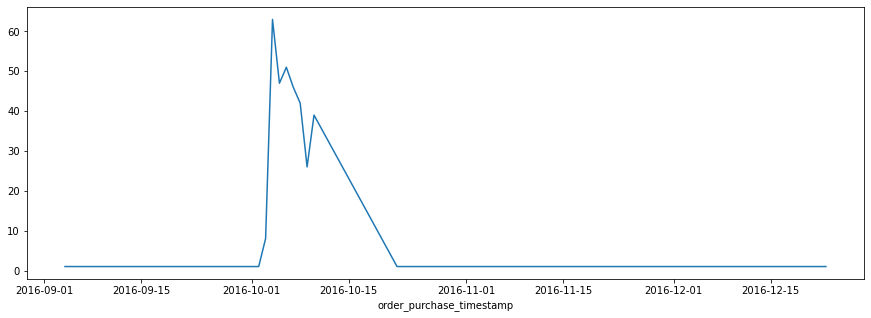

In [33]:
plt.figure(figsize=(15, 5))
orders[orders['order_purchase_timestamp'] < '2017-1-5'].groupby(orders['order_purchase_timestamp'].dt.date)['order_id'].count().plot()

<AxesSubplot:xlabel='order_purchase_timestamp'>

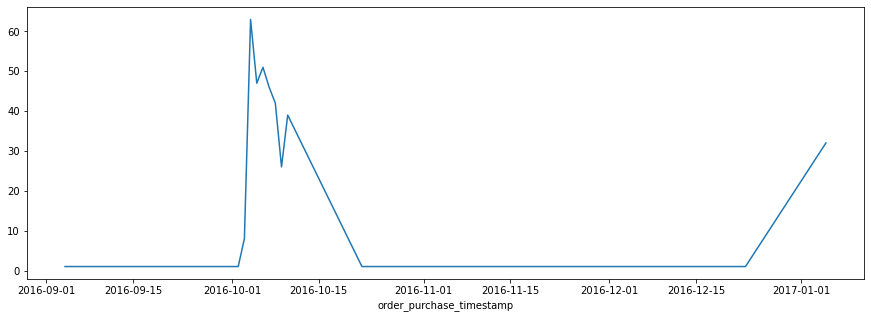

In [34]:
plt.figure(figsize=(15, 5))
orders[orders['order_purchase_timestamp'] < '2017-1-6'].groupby(orders['order_purchase_timestamp'].dt.date)['order_id'].count().plot()

<AxesSubplot:xlabel='order_purchase_timestamp'>

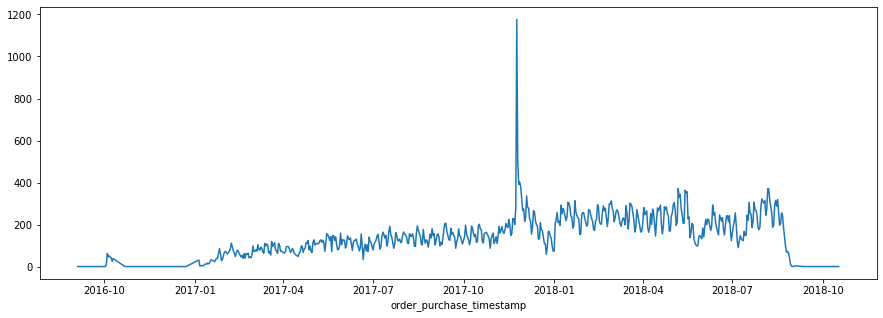

In [23]:
plt.figure(figsize=(15, 5))
orders.groupby(orders['order_purchase_timestamp'].dt.date)['order_id'].count().plot()

In [24]:
# when is this peak of orders: 1 month before christmas
print(orders1.groupby(orders1['order_purchase_timestamp'].dt.date)['order_id'].count().idxmax())
# how many orders were on that date:
print(orders1.groupby(orders1['order_purchase_timestamp'].dt.date)['order_id'].count().max())

2017-11-24
1176


for segmentation in the next notebook: to check the behavior of the clients that made their orders from January to July (6 month). Result: these clients made very few orders in the future, so they are supposed to stay within the same cluster for all the duration of the existence of the dataset.

2016-09-04 21:15:19
2018-10-17 17:30:18
772 days 20:14:59


<AxesSubplot:xlabel='order_purchase_timestamp'>

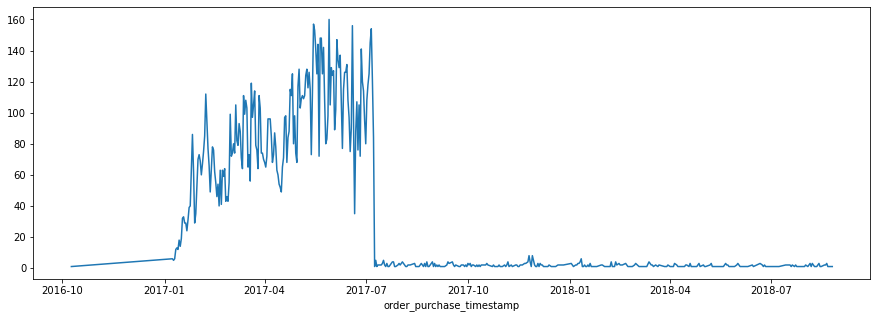

In [35]:
print(orders1.order_purchase_timestamp.min())
print(orders1.order_purchase_timestamp.max())
print(orders1.order_purchase_timestamp.max() - orders1.order_purchase_timestamp.min())

# test = orders1[(orders1.order_purchase_timestamp < '2017-9-4')].customer_unique_id
test = orders1[(orders1.order_purchase_timestamp > '2017-1-8') & (orders1.order_purchase_timestamp < '2017-7-9')].customer_unique_id
test_d = orders1[orders1.customer_unique_id.isin(test)]

plt.figure(figsize=(15, 5))
test_d.groupby(test_d['order_purchase_timestamp'].dt.date)['order_id'].count().plot()

<AxesSubplot:>

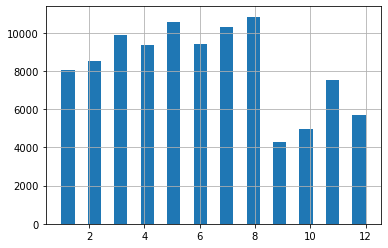

In [36]:
orders1.order_purchase_timestamp.dt.month.hist(bins=23)
# fewer in 9,10 and 12, more in 5, 7, 8, not a lot in 11

In [37]:
orders1['month'] = orders1.order_purchase_timestamp.dt.month
orders1['month'] = orders1['month'].apply(int)
# when aggregate, don't use mean! use the most frequent value.

<AxesSubplot:>

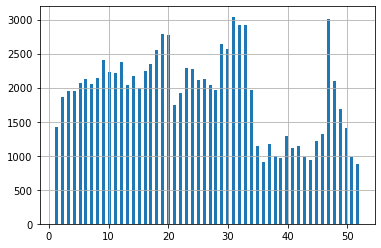

In [38]:
orders1.order_purchase_timestamp.dt.isocalendar().week.hist(bins=103)
# look what we see! week 47 explodes more than peaks in "fat" month 5,7,8

In [39]:
orders1['weekofyear'] = orders1.order_purchase_timestamp.dt.isocalendar().week
orders1['weekofyear'] = orders1['weekofyear'].apply(int)
# when aggregate, don't use mean! use the most frequent value.

<AxesSubplot:>

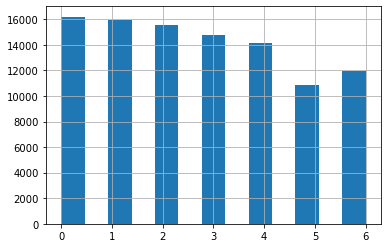

In [40]:
orders1.order_purchase_timestamp.dt.dayofweek.hist(bins=13)
# slighly more on monday and tuesday, less on weeekends

<AxesSubplot:>

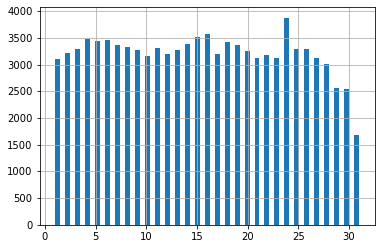

In [41]:
orders1.order_purchase_timestamp.dt.day.hist(bins=61)
# no distinction by the day of month
# 3 waves can be a result of random

<AxesSubplot:>

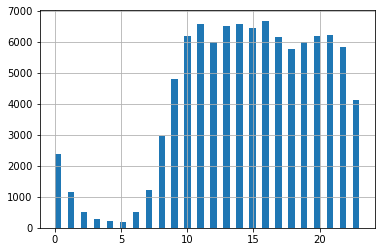

In [42]:
orders1.order_purchase_timestamp.dt.hour.hist(bins=47)
# no distinction by the day of month
# 3 waves can be a result of random

In [43]:
week_month_order = orders1.groupby('customer_id').agg({'customer_unique_id': 'last', 
                                                       'weekofyear': 'last',
                                                       'month': 'last',
                                                      })
                                                               
# note: here we can take last or first, because inside THE SAME ORDER, the client id is the same. 
# And the the date of THE SAME ORDER is the same, so the week and the month are the same.

In [44]:
week_month_client = week_month_order.groupby('customer_unique_id').agg(lambda x:x.mode()[0])

In [45]:
final = pd.merge(final, week_month_client, how = 'left', on='customer_unique_id')

### Feature engineering: mean time between orders (but 96.88% clients made only 1 order) and recency

In [46]:
print('clients in the table:', final.shape[0])
print('clients made all their orders in 1 day:', final[final.first_order == final.last_order].shape[0])
print('But some of them still made more than 1 order. See below:')
final[final.first_order == final.last_order].n_orders.value_counts()

clients in the table: 96096
clients made all their orders in 1 day: 93356
But some of them still made more than 1 order. See below:


1    93099
2      255
3        2
Name: n_orders, dtype: int64

In [47]:
# frequency is (last purchase date - first purchase) / number of orders
# if a client made only one order (as 97% of the clients!)
# then frequency is (the last purchase date of all dataset - first order date) / number of orders
# recency is how many days have gone since last purchase

max_date = orders1['order_purchase_timestamp'].max()

def temp(x):
    if x.first_order == x.last_order:
        return ((max_date - x.first_order).days) / x.n_orders # if 2 orders were made in 1 day
    else:
        return ((x.last_order - x.first_order).days) / x.n_orders

final['frequency'] = final.apply(temp, axis=1) #passes a Series object, row-wise

# final['recency'] = max_date - final.last_order.dt.days
final['recency'] = max_date - final.last_order
final['recency'] = final['recency'].dt.days

# When i tried to use list comprehension with (final[final.first_order == final.last_order) as "if" condition,
# ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

<AxesSubplot:>

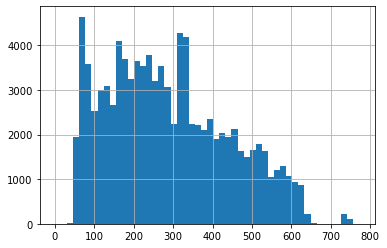

In [49]:
final.recency.hist(bins=50)

<AxesSubplot:>

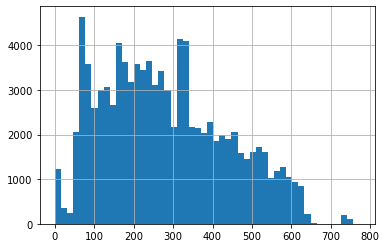

In [50]:
final.frequency.hist(bins=50)

In [51]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   n_orders         96096 non-null  int64         
 1   statuses         96096 non-null  object        
 2   app_pur          96096 non-null  float64       
 3   car_pur          96096 non-null  float64       
 4   car_app          96096 non-null  float64       
 5   deliv_pur        96096 non-null  float64       
 6   estim_deliv_pur  96096 non-null  int64         
 7   deliv_app        96096 non-null  float64       
 8   deliv_delay      96096 non-null  float64       
 9   first_order      96096 non-null  datetime64[ns]
 10  last_order       96096 non-null  datetime64[ns]
 11  weekofyear       96096 non-null  int64         
 12  month            96096 non-null  int64         
 13  frequency        96096 non-null  float

## Information from table "items"

In [52]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [53]:
items['shipping_limit_date'] = items['shipping_limit_date'].astype('datetime64[ns]')

- order_id (key) (98666 unique values) (link to 'orders' dataset): order unique identifier
- order_item_id (key) (mainly 1): sequential number identifying number of items included in the same order.
- product_id (key) (32951 unique values) (link to 'products' dataset): product unique identifier
- seller_id (key) (2% one, 2% another and 108630 others) (link to 'sellers' dataset): seller unique identifier
- shipping_limit_date: it shows the seller shipping limit date for handling the order over to the logistic partner.
- price: item price
- freight_value: item freight value item. if an order has more than one item the freight value is splitted between items.

In [54]:
items1 = pd.merge(orders1, items,
                       how='left',
                       on='order_id')
print(orders1.shape)
print(items1.shape)

(99441, 22)
(113425, 28)


- order_delivered_carrier_date: Shows the order posting timestamp. When it was handled to the logistic partner.
- shipping_limit_date: it shows the seller shipping limit date for handling the order over to the logistic partner.

I want to check if some items were handled to the logistic partner late (avec du retard), so that the delay in the delivery comes from the seller, not from the logistic partner.

For aggregation, I will take the maximum seller delay.

In [55]:
items1['seller_delay'] = items1.order_delivered_carrier_date - items1.shipping_limit_date
items1['seller_delay'] = items1.seller_delay.dt.days
items1['seller_delay'].mean()

# items1['seller_delay'] = items1.seller_delay.fillna(items1.seller_delay.max())
items1['seller_delay'] = items1.seller_delay.fillna(items1.seller_delay.mean())
# items1['seller_delay'] = items1.seller_delay.fillna(items1.seller_delay.mode().iloc[0])

<AxesSubplot:>

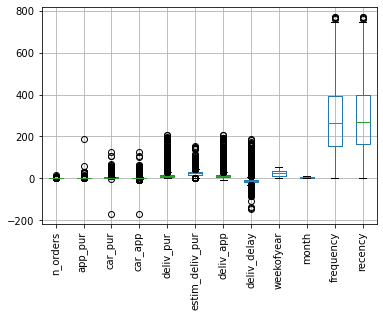

In [56]:
final.boxplot(rot=90)

I want to have a price of an average item that a client buys (1), and an average price per order for a client(2), and total price spent(3).

Then all the same for the freight value: average freight of an item that client pays(1), average freight of an order that client pays(2), and total freight spent(3).

1. Aggregation by client, mean
2. Aggregation by order, sum; then by client, mean
3. Aggregation by client, sum. Or by order, sum, then by client, sum. It should give the same results.

Then all the same for ratio freight/object: per item (1), per order(2), and total(3).

In [57]:
# this way the difference is more remarkable
items1['f_ratio_item'] = items1.freight_value / items1.price
# items1['f_ratio_item'] = items1.freight_value / (items1.price + items1.freight_value)

In [58]:
items_gr_client = items1.groupby('customer_unique_id')
items_aggr_client = items_gr_client.agg({
    'seller_delay': 'mean',
    'price': 'mean',
    'freight_value': 'mean',
    'f_ratio_item': 'mean',
#     'order_item_id': 'count'
})
items_aggr_client = items_aggr_client.rename(columns={'price': 'price_item', 
                                                      'freight_value': 'freight_item', 'order_item_id': 'total_n_items'})

In [59]:
print(final.shape)
final = pd.merge(final, items_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 15)
(96096, 19)


In [60]:
# customer unique id is THE SAME in the same order, so we can take first or last, doesn't matter
items_gr_order = items1.groupby('customer_id')
items_aggr_order = items_gr_order.agg({
    'customer_unique_id': 'first',
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'
})
items_aggr_order = items_aggr_order.rename(columns={'price': 'price_order',
                                                    'freight_value': 'freight_order',
                                                    'order_item_id': 'items_in_order'})

In [61]:
# this way the difference is more remarkable
items_aggr_order['f_ratio_order'] = items_aggr_order.freight_order / items_aggr_order.price_order
# items_aggr_order['f_ratio_order'] = items_aggr_order.freight_order / (items_aggr_order.price_order + items_aggr_order.freight_order)

In [62]:
items_gr_order_client = items_aggr_order.groupby('customer_unique_id')
items_aggr_order_client = items_gr_order_client.agg({
    'price_order': 'mean',
    'freight_order': 'mean',
    'f_ratio_order': 'mean',
    'items_in_order': 'max'
})

In [63]:
print(final.shape)
final = pd.merge(final, items_aggr_order_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 19)
(96096, 23)


In [64]:
# just to remind:
# items_gr_client = items1.groupby('customer_unique_id')

items_aggr_client = items_gr_client.agg({
    'price': 'sum',
    'freight_value': 'sum',
})
items_aggr_client = items_aggr_client.rename(columns={'price': 'price_total', 'freight_value': 'freight_total'})

In [65]:
items_aggr_client['f_ratio_total'] = items_aggr_client.freight_total / items_aggr_client.price_total
# items_aggr_client['f_ratio_total'] = items_aggr_client.freight_total / (items_aggr_client.price_total + items_aggr_client.freight_total)

In [66]:
print(final.shape)
final = pd.merge(final, items_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 23)
(96096, 26)


In [67]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   n_orders         96096 non-null  int64         
 1   statuses         96096 non-null  object        
 2   app_pur          96096 non-null  float64       
 3   car_pur          96096 non-null  float64       
 4   car_app          96096 non-null  float64       
 5   deliv_pur        96096 non-null  float64       
 6   estim_deliv_pur  96096 non-null  int64         
 7   deliv_app        96096 non-null  float64       
 8   deliv_delay      96096 non-null  float64       
 9   first_order      96096 non-null  datetime64[ns]
 10  last_order       96096 non-null  datetime64[ns]
 11  weekofyear       96096 non-null  int64         
 12  month            96096 non-null  int64         
 13  frequency        96096 non-null  float

## Information from the table "payments"

In [68]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


- order_id (key) (99440 unique values) (link to 'orders' dataset): unique identifier of an order.
- payment_sequential: a customer may pay an order with more than one payment method. If he does so, a sequence will be created to accommodate all payments.
- payment_type: method of payment chosen by the customer.
- payment_installments: number of installments chosen by the customer.
- payment_value: transaction value.

In [69]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [70]:
payments[payments.payment_installments < 1]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [71]:
payments.loc[payments.payment_installments < 1, 'payment_installments'] = 1

In [72]:
payments.loc[payments.payment_type == 'not_defined', 'payment_type'] = 'credit_card'

In [73]:
payments[payments.order_id == '332c6742772f2df936696b6512b10edb']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
199,332c6742772f2df936696b6512b10edb,2,credit_card,6,134.55
62830,332c6742772f2df936696b6512b10edb,1,credit_card,1,8.70


Please note! that number of installments is not reflected in larger number of payment sequentials. 

An order can have large nuber of installments, and only one payment (but it means that s/he paid several times, because it's an installment).

But another order can have many payment_sequential, but each with 1 installments! Meaning that s/he has payed all at once.

To resume, many payment_sequential don't mean increasing number of installments.

In [74]:
payments[payments.order_id == '510bff1cf06be1143d3b6698df2fd486']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
2191,510bff1cf06be1143d3b6698df2fd486,2,credit_card,8,406.38


In [75]:
payments[payments.order_id == 'a079628ac8002126e75f86b0f87332e4']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
10258,a079628ac8002126e75f86b0f87332e4,3,credit_card,3,102.82
36471,a079628ac8002126e75f86b0f87332e4,2,debit_card,1,50.00


Why payment_installments values are diffrerent for the same order, what happened in these orders? Maybe it's because there are several items in an order, and one is payed with installment, and another is payed all at once?

Where is payment 1 here, what happened? It has payment_sequential 2 and 3, but not 1.

In [76]:
# sns.countplot(data=payments, x='payment_type', saturation=1)

But is it that interesting what is the way of payment? Maybe at final selection of varibales, I will drop all the variables related to means of payment.

In [77]:
payments['notcrcard'] = True
payments.loc[payments.payment_type == 'credit_card', 'notcrcard'] = False

In [78]:
for ptype in payments.payment_type.unique():
    payments[ptype] = False
    payments.loc[payments.payment_type == ptype, ptype] = True

In [79]:
payments1 = pd.merge(orders1, payments,
                       how='left',
                       on='order_id')
print(orders1.shape)
print(payments1.shape)

(99441, 22)
(103887, 31)


In [80]:
payments1['notcrcard'] = payments1['notcrcard'].fillna(False)

In [81]:
for ptype in payments1.payment_type.dropna().unique(): # if you don't write dropna here, it takes NaNs too and rises an error
    payments1[ptype] = payments1[ptype].fillna(False)

I want to have an average payment that a client pays (1), and an average payment per order for a client(2), and the total payment made(3).

Payment installments - mean number per order (2) and maximal number overall (3).

About mean number per payment (1): I'm not sure if this metric is useful. Even though some order were made indeed with unequal number of installments, this doesn't tell us anything useful about cient behavior.

Payment type - two appoaches.
1. Say for every payment type if it was used by a given client.
2. Just one column: to see if they use sometimes other payments than the most popular one.

I will try both of these methods, but during clustering I will use only 1 of them.

Payment sequential means just iterative number within an order, shows how many payments were made. It carries no information for our purpose.

1. Aggregation by client, mean
2. Aggregation by order, sum; then by client, mean
3. Aggregation by client, sum. Or by order, sum, then by client, sum. It should give the same results.

Then all the same for ratio freight/object: per item (1), per order(2), and total(3).


__Why I finally aggregate only "voucher" metric: if a client pays with vouchers, you can send him proposals about voucher/cupons.__

In [82]:
payments1[payments1.payment_sequential.isna()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,weekofyear,payment_sequential,payment_type,payment_installments,payment_value,notcrcard,credit_card,boleto,voucher,debit_card
22061,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,...,37,NaN,NaN,NaN,NaN,False,False,False,False,False


In [83]:
payments_gr_client = payments1.groupby('customer_unique_id')
payments_aggr_client = payments_gr_client.agg({
    'payment_value': 'mean',
    'payment_installments': 'max',
    'payment_sequential': 'max',
#     'notcrcard': 'sum',
#     'credit_card': 'sum',
#     'boleto': 'sum',
    'voucher': 'sum',
#     'debit_card': 'sum',
})
payments_aggr_client = payments_aggr_client.rename(columns={'payment_value': 'pay_aver', 
                                                            'payment_installments': 'installm_max'})

In [84]:
print(final.shape)
final = pd.merge(final, payments_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 26)
(96096, 30)


In [85]:
# # these variables are highly correlated with other price variables and payment variables.

# payments_gr_order = payments1.groupby('customer_id')
# payments_aggr_order = payments_gr_order.agg({
#     'customer_unique_id': 'first',
#     'payment_value': 'sum',
#     'payment_installments': 'sum',
# })
# payments_aggr_order = payments_aggr_order.rename(columns={'payment_value': 'pay_order', 
#                                                           'payment_installments': 'installm_sum_order'})

# payments_gr_order_client = payments_aggr_order.groupby('customer_unique_id')
# payments_aggr_order_client = payments_gr_order_client.agg({
#     'pay_order': 'mean',
#     'installm_sum_order': 'mean',
# })

# print(final.shape)
# final = pd.merge(final, payments_aggr_order_client, how='left', on='customer_unique_id')
# print(final.shape)

In [86]:
payments_gr_client = payments1.groupby('customer_unique_id')
payments_aggr_client = payments_gr_client.agg({
    'payment_value': 'sum',
})
payments_aggr_client = payments_aggr_client.rename(columns={'payment_value': 'pay_total'})

In [87]:
print(final.shape)
final = pd.merge(final, payments_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 30)
(96096, 31)


In [88]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   n_orders            96096 non-null  int64         
 1   statuses            96096 non-null  object        
 2   app_pur             96096 non-null  float64       
 3   car_pur             96096 non-null  float64       
 4   car_app             96096 non-null  float64       
 5   deliv_pur           96096 non-null  float64       
 6   estim_deliv_pur     96096 non-null  int64         
 7   deliv_app           96096 non-null  float64       
 8   deliv_delay         96096 non-null  float64       
 9   first_order         96096 non-null  datetime64[ns]
 10  last_order          96096 non-null  datetime64[ns]
 11  weekofyear          96096 non-null  int64         
 12  month               96096 non-null  int64        

## Information from table "reviews"

In [89]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   review_id                100000 non-null  object
 1   order_id                 100000 non-null  object
 2   review_score             100000 non-null  int64 
 3   review_comment_title     11715 non-null   object
 4   review_comment_message   41753 non-null   object
 5   review_creation_date     100000 non-null  object
 6   review_answer_timestamp  100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


- review_id (key) (99173 unique values): unique review identifier
- order_id (key) (99441 unique values) (link to 'orders' dataset): unique order identifier
- review_score: Note ranging from 1 to 5 given by the customer on a satisfaction survey.
- review_comment_title: Comment title from the review left by the customer, in Portuguese.
- review_comment_message: Comment message from the review left by the customer, in Portuguese.
- review_creation_date: Shows the date in which the satisfaction survey was sent to the customer.
- review_answer_timestamp: Shows satisfaction survey answer timestamp.

In [90]:
reviews1 = pd.merge(orders1, reviews,
                       how='left',
                       on='order_id')
print(orders1.shape)
print(reviews1.shape)

(99441, 22)
(100000, 28)


In [91]:
# reviews_gr_client = reviews1.groupby('customer_unique_id')
# reviews_aggr_client = reviews_gr_client.agg({
#     'review_score': 'min',
# })
# reviews_aggr_client = reviews_aggr_client.rename(columns={'review_score': 'review_min'})

# print(final.shape)
# final = pd.merge(final, reviews_aggr_client, how='left', on='customer_unique_id')
# print(final.shape)

In [92]:
reviews_gr_client = reviews1.groupby('customer_unique_id')
reviews_aggr_client = reviews_gr_client.agg({'review_score': 'mean'})
reviews_aggr_client = reviews_aggr_client.rename(columns={'review_score': 'review_mean'})

print(final.shape)
final = pd.merge(final, reviews_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 31)
(96096, 32)


In [93]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   n_orders            96096 non-null  int64         
 1   statuses            96096 non-null  object        
 2   app_pur             96096 non-null  float64       
 3   car_pur             96096 non-null  float64       
 4   car_app             96096 non-null  float64       
 5   deliv_pur           96096 non-null  float64       
 6   estim_deliv_pur     96096 non-null  int64         
 7   deliv_app           96096 non-null  float64       
 8   deliv_delay         96096 non-null  float64       
 9   first_order         96096 non-null  datetime64[ns]
 10  last_order          96096 non-null  datetime64[ns]
 11  weekofyear          96096 non-null  int64         
 12  month               96096 non-null  int64        

## Information about customers location

I think I will not add the seller's location, because the clients not necessarily know or are interested in where they order a good from. So, this information, seller's location and the distance between seller and customer, will not add anything useful to the investigation

In [94]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [95]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


- geolocation_zip_code_prefix (link to 'customers' and 'sellers' datasets): first 5 digits of zip code
- geolocation_lat: latitude
- geolocation_lng: longitude
- geolocation_city: city
- geolocation_state: state

mean lines per 1 geolocation zip code: 52.598632658427555
max lines per 1 geolocation zip code: 1146
min zip code 1001
max zip code 99990


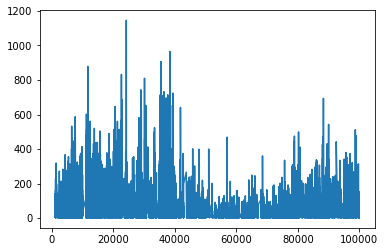

In [96]:
print('mean lines per 1 geolocation zip code:', geolocation.groupby('geolocation_zip_code_prefix').count().mean()[0])
print('max lines per 1 geolocation zip code:', geolocation.groupby('geolocation_zip_code_prefix').count().max()[0])
print('min zip code', geolocation.geolocation_zip_code_prefix.min())
print('max zip code', geolocation.geolocation_zip_code_prefix.max())

plt.plot(geolocation.groupby('geolocation_zip_code_prefix')['geolocation_lat'].count())
plt.show()

In [97]:
print('unique values for customer zip codes:', customers.customer_zip_code_prefix.nunique())
print('unique values for geolocation zip codes:', geolocation.geolocation_zip_code_prefix.nunique())
zip_loc = set(geolocation.geolocation_zip_code_prefix.unique())
zip_cust = set(customers.customer_zip_code_prefix.unique())
print('customer zip code prefixes absent in geolocation:', len(zip_cust.difference(zip_loc)))

unique values for customer zip codes: 14994
unique values for geolocation zip codes: 19015
customer zip code prefixes absent in geolocation: 157


In [98]:
print('max locations with the same city:', geolocation.groupby('geolocation_city')['geolocation_lat'].count().max())
print('average locations with the same city:', geolocation.groupby('geolocation_city')['geolocation_lat'].count().mean())
print('median locations with the same city:', geolocation.groupby('geolocation_city')['geolocation_lat'].count().median())
print('number of unique city names:', geolocation.geolocation_city.nunique())

max locations with the same city: 135800
average locations with the same city: 124.84870802646361
median locations with the same city: 12.0
number of unique city names: 8011


Not all customers zip codes are present in geolocation zip codes. 157 unique customers zip code prefixes cannot be addressed to latitude or longitude.

Even in the customers dataset some customers can have more than 1 location (up to 3 in this dataset).

In [99]:
print('unique values for customer cities:', customers.customer_city.nunique())
print('unique values for geolocation cities:', geolocation.geolocation_city.nunique())
city_geoloc = set(geolocation.geolocation_city.unique())
city_cust = set(customers.customer_city.unique())
print('customer cities absent in geolocation:', len(city_cust.difference(city_geoloc)))

unique values for customer cities: 4119
unique values for geolocation cities: 8011
customer cities absent in geolocation: 50


With cities if will not work neither.
Not all customers cities are present in geolocation zip codes. 50 customers unique cities cannot be addressed to latitude or longitude.

In [100]:
print('unique values for customer states:', customers.customer_state.nunique())
print('unique values for geolocation cities:', geolocation.geolocation_state.nunique())
state_geoloc = set(geolocation.geolocation_state.unique())
state_cust = set(customers.customer_state.unique())
print('customer states absent in geolocation:', len(state_cust.difference(state_geoloc)))

unique values for customer states: 27
unique values for geolocation cities: 27
customer states absent in geolocation: 0


In [101]:
geolocation[geolocation.geolocation_city == 'adamantina'].head()
geolocation[geolocation.geolocation_city == 'água fria']

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
701052,48170,-11.867199,-38.758379,água fria,BA
701213,48170,-11.888133,-38.767663,água fria,BA
718648,55168,-8.014421,-34.900604,água fria,PE


In [102]:
test = geolocation.groupby(['geolocation_zip_code_prefix', 'geolocation_city']).mean()

In [103]:
test.loc[(slice(None), 'água fria'), :]
test.xs('adamantina', level='geolocation_city')

,geolocation_lat,geolocation_lng
geolocation_zip_code_prefix,,
7097,-23.444346,-46.539030
17800,-21.684239,-51.076015


In [104]:
customers1 = pd.merge(customers, test, 
                      how='left', 
                      left_on=['customer_zip_code_prefix', 'customer_city'], 
                      right_on=['geolocation_zip_code_prefix', 'geolocation_city'])
print(customers.shape)
print(customers1.shape)

(99441, 5)
(99441, 7)


In [105]:
customers1[customers1.customer_city == 'água fria']
customers1[customers1.customer_city == 'adamantina'].head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng
901,ed35271185aa3ecf2e421970e47e473f,643b807a55c5add3c91379b31f50d206,17800,adamantina,SP,-21.684239,-51.076015
5302,9c8238260ea546e75c56fc27c0fedfc8,c7cd7684e4c3d80651bca76f2e7d9b7b,17800,adamantina,SP,-21.684239,-51.076015
8984,f5219627819a30474a6ef14e1598e7f4,d36eba3490c536bfdecc22e3c68ad453,17800,adamantina,SP,-21.684239,-51.076015
9358,5684f8bf0ee27f2003ba2380c4ba8b08,12caadb5a521dab786cd45e51272dddc,17800,adamantina,SP,-21.684239,-51.076015
11492,cc6a744ba14a060493fb64b97087006c,f4aeb606b01219f9277b55d672719071,17800,adamantina,SP,-21.684239,-51.076015


In [106]:
customers1.info() # 318 lines to fill out of 99,441

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               99441 non-null  object 
 1   customer_unique_id        99441 non-null  object 
 2   customer_zip_code_prefix  99441 non-null  int64  
 3   customer_city             99441 non-null  object 
 4   customer_state            99441 non-null  object 
 5   geolocation_lat           99123 non-null  float64
 6   geolocation_lng           99123 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.1+ MB


Now what is my plan: I want to fill NaN with mean latitudes and longitudes values for states. There are 27 states.

In [107]:
state_coords_for_fill = geolocation.groupby('geolocation_state').mean()

In [108]:
for state in state_coords_for_fill.index:
    customers1.loc[(customers1.geolocation_lat.isna()) & (customers1.customer_state == state), 
                   'geolocation_lat'] = state_coords_for_fill.loc[state, 'geolocation_lat']

for state in state_coords_for_fill.index:
    customers1.loc[(customers1.geolocation_lng.isna()) & (customers1.customer_state == state), 
                   'geolocation_lng'] = state_coords_for_fill.loc[state, 'geolocation_lng']

customers1 = customers1.rename(columns={'geolocation_lat': 'customer_lat', 'geolocation_lng': 'customer_lng'})    

In [109]:
print(customers1.customer_lat.nunique(), customers1.customer_lng.nunique())

14879 14879


In [110]:
print(customers1.shape)
customers1 = pd.merge(customers1, state_coords_for_fill[['geolocation_lat', 'geolocation_lng']], 
                      how='left', 
                      left_on='customer_state', 
                      right_on='geolocation_state')
print(customers1.shape)

(99441, 7)
(99441, 9)


### Feature engineering: client distance and simplified distance (state mean distance)

I take the distance from Olist headquarters. Even though the goods are not delivered from headquaters, but from warehouses, I need a point from which to calculate the distance.

(maybe instead measure the distance between client location and seller location?)

In [111]:
# Olist headquarters from Google: latitude -25.430572, longitude -49.2920136

customers1['cust_olist_distance'] = np.sqrt((customers1['customer_lat'] + 25.430572) ** 2 + 
                                (customers1['customer_lng'] + 49.2920136) ** 2)

client_gr_client = customers1.groupby('customer_unique_id')
client_aggr_client = client_gr_client.agg({'cust_olist_distance': 'mean'})
client_aggr_client = client_aggr_client.rename(columns={'cust_olist_distance': 'cust_dist_mean'})

print(final.shape)
final = pd.merge(final, client_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 32)
(96096, 33)


In [112]:
# Olist headquarters from Google: latitude -25.430572, longitude -49.2920136

customers1['state_olist_distance'] = np.sqrt((customers1['geolocation_lat'] + 25.430572) ** 2 + 
                                (customers1['geolocation_lng'] + 49.2920136) ** 2)

client_gr_client = customers1.groupby('customer_unique_id')
client_aggr_client = client_gr_client.agg({'state_olist_distance': 'mean'})
client_aggr_client = client_aggr_client.rename(columns={'state_olist_distance': 'state_dist_mean'})

print(final.shape)
final = pd.merge(final, client_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 33)
(96096, 34)


In [113]:
final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96096 entries, 0000366f3b9a7992bf8c76cfdf3221e2 to ffffd2657e2aad2907e67c3e9daecbeb
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   n_orders            96096 non-null  int64         
 1   statuses            96096 non-null  object        
 2   app_pur             96096 non-null  float64       
 3   car_pur             96096 non-null  float64       
 4   car_app             96096 non-null  float64       
 5   deliv_pur           96096 non-null  float64       
 6   estim_deliv_pur     96096 non-null  int64         
 7   deliv_app           96096 non-null  float64       
 8   deliv_delay         96096 non-null  float64       
 9   first_order         96096 non-null  datetime64[ns]
 10  last_order          96096 non-null  datetime64[ns]
 11  weekofyear          96096 non-null  int64         
 12  month               96096 non-null  int64        

## Translate categories for products table

- product_id (key) (32951 unique values) (link to 'items' dataset): unique product identifier
- product_category_name: root category of product, in Portuguese.
- product_name_lenght: number of characters extracted from the product name.
- product_description_lenght: number of characters extracted from the product description.
- product_photos_qty: number of product published photos
- product_weight_g: product weight measured in grams.
- product_length_cm: product length measured in centimeters.
- product_height_cm: product height measured in centimeters.
- product_width_cm: product width measured in centimeters.

- product_category_name (71 unique values): category name in Portuguese
- product_category_name_english (71 unique values): category name in English

In [114]:
products = pd.merge(products, categories_en,
                    how='left',
                    on='product_category_name')

products.drop('product_category_name', axis=1, inplace=True)
products = products.rename(columns={'product_category_name_english': 'product_category_name'})

In [115]:
print(products.product_category_name.nunique())
products.product_category_name.sort_values().unique()

71


array(['agro_industry_and_commerce', 'air_conditioning', 'art',
       'arts_and_craftmanship', 'audio', 'auto', 'baby', 'bed_bath_table',
       'books_general_interest', 'books_imported', 'books_technical',
       'cds_dvds_musicals', 'christmas_supplies', 'cine_photo',
       'computers', 'computers_accessories', 'consoles_games',
       'construction_tools_construction', 'construction_tools_lights',
       'construction_tools_safety', 'cool_stuff',
       'costruction_tools_garden', 'costruction_tools_tools',
       'diapers_and_hygiene', 'drinks', 'dvds_blu_ray', 'electronics',
       'fashio_female_clothing', 'fashion_bags_accessories',
       'fashion_childrens_clothes', 'fashion_male_clothing',
       'fashion_shoes', 'fashion_sport', 'fashion_underwear_beach',
       'fixed_telephony', 'flowers', 'food', 'food_drink',
       'furniture_bedroom', 'furniture_decor', 'furniture_living_room',
       'furniture_mattress_and_upholstery', 'garden_tools',
       'health_beauty', 'home

We have 71 product category. it means, if I apply product category for clustering, this clustering will have 71 more dimensions, totally 100 dimensions!
But probably not all of them are present in orders.

In [116]:
products['product_category_name'] = products.product_category_name.fillna('cool_stuff')
# products['product_weight_g'] = products.product_weight_g.fillna(median())
print('most frequent weight value:', products.product_weight_g.mode())
products['product_weight_g'] = products.product_weight_g.fillna(products.product_weight_g.mode()[0])

most frequent weight value: 0    200.0
dtype: float64


In [117]:
products1 = pd.merge(items1, products, how='left', on='product_id')
print(items1.shape)
print(products1.shape)

(113425, 30)
(113425, 38)


In [118]:
print(products1.product_category_name.nunique())

71


No, all of them are present, that means 71 extra dimensions for analysis.

I can include the product category as "yes-or-no", as I did with statuses or means of payment; or aggregate not as "yes-or-no" but as sum, as I did with "total number of items"; or aggregate with mean, as I did for 'price per item - that will give the proportion of this category from all the purchased atoms.

But I will not add 71 dimension to the clustering - it causes "dimensionality curse", and either you don't have clusters at all, or have them only based on categories. 
It's more logical to segment the customers for consumption, frequency and recency, and then check which products a certain client consumes.

### Check which parameters of product impact on customer choice

Products presented in marketplace (mode)

In [119]:
products[['product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm']].mode().loc[0]

product_name_lenght            60.0
product_description_lenght    404.0
product_photos_qty              1.0
product_weight_g              200.0
product_length_cm              16.0
product_height_cm              10.0
product_width_cm               11.0
Name: 0, dtype: float64

Products bought (mode)

In [120]:
products1[['product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm']].mode().loc[0]

product_name_lenght            59.0
product_description_lenght    341.0
product_photos_qty              1.0
product_weight_g              200.0
product_length_cm              16.0
product_height_cm              10.0
product_width_cm               20.0
Name: 0, dtype: float64

Tendencies - people prefer buy products with shorter descriptions and WIDER! (what?)

<AxesSubplot:>

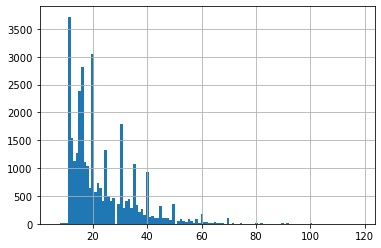

In [121]:
products.product_width_cm.hist(bins=int(products.product_width_cm.max()-1))

<AxesSubplot:>

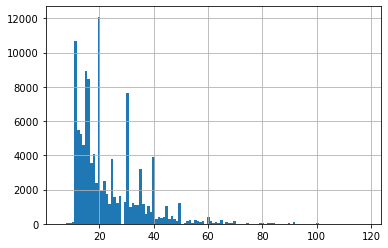

In [122]:
products1.product_width_cm.hist(bins=int(products1.product_width_cm.max()-1))

Products presented in marketplace (median)

- product_name_lenght            51.0
- product_description_lenght    595.0
- product_photos_qty              1.0
- product_weight_g              700.0
- product_length_cm              25.0
- product_height_cm              13.0
- product_width_cm               20.0

Products bought (median)
- product_name_lenght            52.0
- product_description_lenght    603.0
- product_photos_qty              1.0
- product_weight_g              700.0
- product_length_cm              25.0
- product_height_cm              13.0
- product_width_cm               20.0

Here we see no preferences in the description length or width.

<AxesSubplot:>

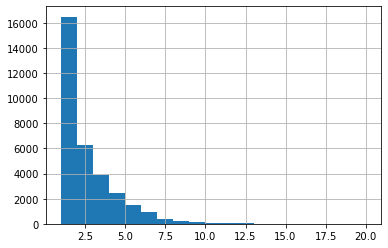

In [123]:
products.product_photos_qty.hist(bins=int(products.product_photos_qty.max()-1))

<AxesSubplot:>

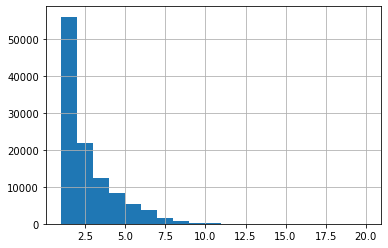

In [124]:
products1.product_photos_qty.hist(bins=int(products1.product_photos_qty.max()-1))

No preferences to higher or lower photos quantity.

Products presented in marketplace (mean)

- product_name_lenght             48.476949
- product_description_lenght     771.495285
- product_photos_qty               2.188986
- product_weight_g              2276.346454
- product_length_cm               30.815078
- product_height_cm               16.937661
- product_width_cm                23.196728

Products bought (mean)
- product_name_lenght             48.775978
- product_description_lenght     787.867029
- product_photos_qty               2.209713
- product_weight_g              2093.369463
- product_length_cm               30.153669
- product_height_cm               16.593766
- product_width_cm                22.996546

Here we could speculate that clients prefere more photos on average, or longer description, but we know from histogram that it's not true.

<AxesSubplot:>

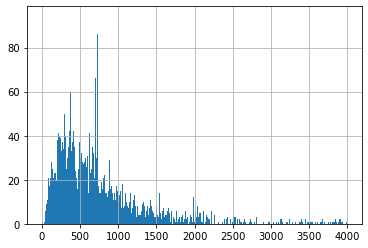

In [125]:
products.product_description_lenght.hist(bins=int(products.product_description_lenght.max()-1))

<AxesSubplot:>

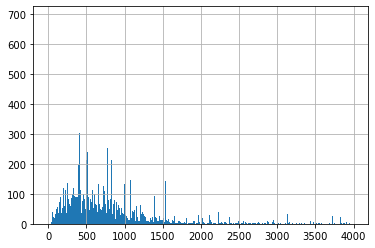

In [126]:
products1.product_description_lenght.hist(bins=int(products1.product_description_lenght.max()-1))

No preferencies to longer or shorter descriptions.

## Information from products table

I want to have an average description length of a product that a customers buys (1), and the same for quantity of photos of a product.
I want to have a mean weight of an order (2).

1. Aggregation by client, mean
2. Aggregation by order, sum; then by client, mean

In [127]:
products_gr_client = products1.groupby('customer_unique_id')
products_aggr_client = products_gr_client.agg({
    'product_description_lenght': 'mean',
    'product_photos_qty': 'mean',
})
products_aggr_client = products_aggr_client.rename(columns={'product_description_lenght': 'prod_descr_mean',
                                                         'product_photos_qty': 'photos_qty_mean'})

print(final.shape)
final = pd.merge(final, products_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 34)
(96096, 36)


In [128]:
products_gr_order = products1.groupby('customer_id')
products_aggr_order = products_gr_order.agg({
    'customer_unique_id': 'first',
    'product_weight_g': 'sum',
})
products_aggr_order = products_aggr_order.rename(columns={'product_weight_g': 'ord_weit_mean'})

products_gr_client = products_aggr_order.groupby('customer_unique_id')
products_aggr_client = products_gr_client.agg({'ord_weit_mean': 'mean'})
print(final.shape)
final = pd.merge(final, products_aggr_client, how='left', on='customer_unique_id')
print(final.shape)

(96096, 36)
(96096, 37)


## Correlations in missing values, fill missing values, select lines and columns

In [129]:
import missingno as msno

The heatmap below shows the correlations in filling, not in values. High correlation means that when one column is NaN, the other is NaN too.

And we don't see the columns that are entirely filled, or entirely empty.

In [260]:
msno.heatmap(final, cmap='coolwarm')

In [261]:
msno.dendrogram(final)

In [130]:
pd.set_option('display.max_columns', None)

In [131]:
final_select = final.loc[final.statuses.str.contains('delivered'), :].copy()
final_thrown = final.loc[~final.statuses.str.contains('delivered'), :]
print('mean review score where at least one order has status "delivered":', final_select.review_mean.mean())
print('mean review score where all orders don\'t have status "delivered":', final_thrown.review_mean.mean())

mean review score where at least one order has status "delivered": 4.139067273117037
mean review score where all orders don't have status "delivered": 1.6986851716581446


In [132]:
final_thrown.review_mean.value_counts()

1.0    1964
5.0     217
3.0     213
2.0     206
4.0     136
3.5       2
Name: review_mean, dtype: int64

In [133]:
final_thrown[final_thrown.review_mean > 3].statuses.value_counts()

shipped        197
canceled        67
unavailable     46
invoiced        32
processing      11
created          1
approved         1
Name: statuses, dtype: int64

From where very important remarque: if you keep only the clients which have status "delivered", you bias yourself: __you become blind to clients__ who are unhappy with your service, and will not understand what's the trouble and what you can change in your strategy.

Nevertheless, it's ok if we get a bit blind here. Let's jusst say that clients who don't have any order delivered, are among the clients who faced some problems. You can abandon them, of, if you prefer, you can check their review score and comments, and if they're dissatisfied, you can write them the apologizes and offer a compensation. But for the future they are out of scope of the clustering.

## Linear correlations between values

In [266]:
# final = final[final.app_pur.notna()]

In [135]:
for_corr1 = final_select.loc[:, ['n_orders', 'app_pur', 'car_pur', 'car_app', 'deliv_pur', 'deliv_app',
       'deliv_delay', 'weekofyear', 'month', 'frequency', 'recency', 'seller_delay', 'price_item',
       'freight_item', 'f_ratio_item', 'price_order', 'freight_order',
       'f_ratio_order', 'price_total', 'freight_total', 'f_ratio_total',
       'pay_aver', 'payment_sequential', 'installm_max', 'pay_total', 
#        'review_min', 'pay_order', 'installm_sum_order',
                  'review_mean', 'cust_dist_mean', 'state_dist_mean', 'prod_descr_mean',
       'photos_qty_mean', 'ord_weit_mean']]

for_corr2 = final_thrown.loc[:, ['n_orders', 'app_pur', 'car_pur', 'car_app', 'deliv_pur', 'deliv_app',
       'deliv_delay', 'weekofyear', 'month', 'frequency', 'recency', 'seller_delay', 'price_item',
       'freight_item', 'f_ratio_item', 'price_order', 'freight_order',
       'f_ratio_order', 'price_total', 'freight_total', 'f_ratio_total',
       'pay_aver', 'payment_sequential', 'installm_max', 'pay_total', 
#        'review_min', 'pay_order', 'installm_sum_order',
                  'review_mean', 'cust_dist_mean', 'state_dist_mean', 'prod_descr_mean',
       'photos_qty_mean', 'ord_weit_mean']]

In [136]:
corr_matr = for_corr1.corr()
# mask = np.zeros_like(corr_matr)
# mask[np.triu_indices_from(mask)] = True # creates an array with 1111, 0111, 0011, 0001, not 0000

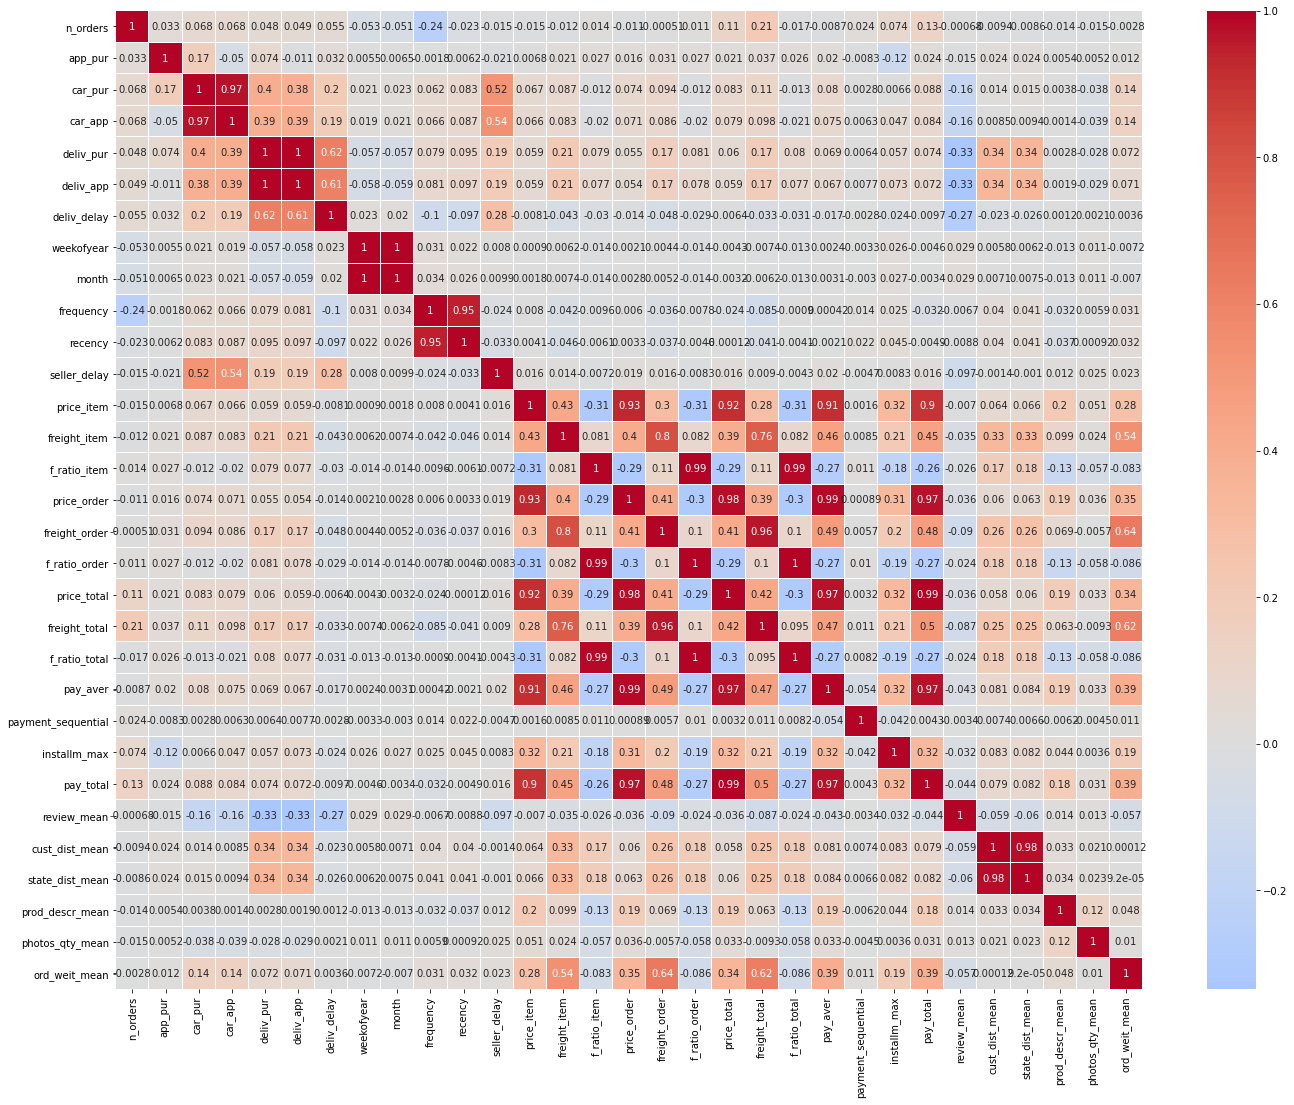

In [137]:
fig = plt.figure(figsize=(23,18))
sns.heatmap(corr_matr, square=False, linewidths=0.01, center=0, annot=True, cmap='coolwarm') # mask=mask, 
# >>># center=0 is a center of the colorscale: to which value the center of the colorscale is assigned
plt.xticks(rotation=90)
plt.show()

#### Highly correlated variables:

- Carrier - approved / carrier-purchased
- Delivery - purchase / delivery - approved
- Weekofyear / month
- Frequency / recency
- Price item / order / total / payment average / payment total
- Freight item / order / total
- Freight ratio item / order / total
- Customer dist mean / state distance mean (less precised)

Note how review is negatively correlated at score -0.3 with delivery delays.

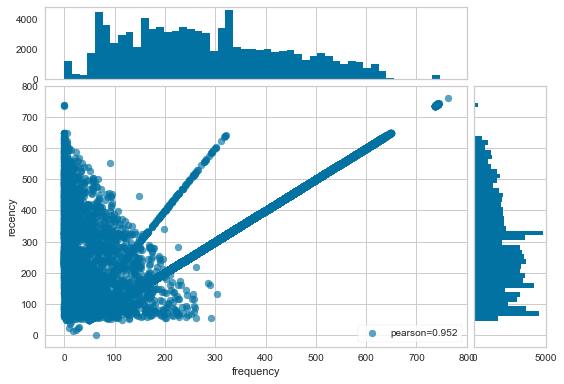

<AxesSubplot:xlabel='frequency', ylabel='recency'>

In [138]:
from yellowbrick.features import JointPlotVisualizer

visualizer = JointPlotVisualizer(columns=['frequency', 'recency'])
visualizer.fit_transform(for_corr1)
visualizer.show()

The main line is 96.88% clients who made only 1 order. Other line refers to as clients who made 2 orders.

## Fill missing values

In [139]:
final[final.isnull().any(axis=1)].statuses.value_counts()

delivered      1259
unavailable     564
canceled        119
shipped          24
processing       11
invoiced          8
created           4
Name: statuses, dtype: int64

In [140]:
final.columns[final.isna().any()]

Index(['price_item', 'freight_item', 'f_ratio_item', 'f_ratio_order',
       'f_ratio_total', 'pay_aver', 'installm_max', 'payment_sequential',
       'prod_descr_mean', 'photos_qty_mean'],
      dtype='object')

In [141]:
final_select[final_select.isnull().any(axis=1)].statuses.value_counts()

delivered    1259
Name: statuses, dtype: int64

In [142]:
final_select.columns[final_select.isna().any()]

Index(['pay_aver', 'installm_max', 'payment_sequential', 'prod_descr_mean',
       'photos_qty_mean'],
      dtype='object')

In [143]:
for col in ['app_pur', 'car_pur', 'car_app', 'deliv_pur', 'deliv_app', 'deliv_delay']:
    final_select.loc[:, col] = final_select[col].fillna(final_select[col].mean())

In [144]:
for col in final_select.columns[final_select.isna().any()]:
    final_select.loc[:, col] = final_select[col].fillna(final_select[col].mode().iloc[0])

## Register the ready dataset

In [145]:
select_vars = final_select[[
    'n_orders',
    'items_in_order', 
    'deliv_pur',
    'weekofyear', 
    'month',
    'frequency',
    'recency',
    'price_item', 
    'price_total',
    'pay_total',
    'pay_aver',
    'payment_sequential',
    'voucher',
    'installm_max',
    'review_mean',
    'f_ratio_total',
    'cust_dist_mean',
    'state_dist_mean',
    ]]

In [278]:
final.to_csv(relativepath + 'olist_segm_clients_all_statuses.csv')
final_select.to_csv(relativepath + 'olist_segm_clients_delivered.csv')
select_vars.to_csv(relativepath + 'olist_segm_clients_select_vars.csv')